**CREAZIONE IL 08/06/2026 FATTO DA SIMONE RAIMONDI**

**NoteBook iniziale grezzo per la Simulazione dei dati iniziali**

In generale questo notebook è un inizio grezzo della simulazione dei dati iniziali e in particolare alcune di queste idee potrebbero essere convertite in files .py qualora le funzioni definite dovessero essere richiamate più volte nel corso del resto dell'analisi.

In [5]:
'''
Cella di import delle librerie utilizzate.
'''
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import emcee as mcmc
import corner as mcmc_vis

%matplotlib ipympl

print('All libraries have been imported.')

All libraries have been imported.


In [6]:
'''
Cella dedicata alla definizione dei parametri della simulazione.
'''
#Numero di stati del sistema:
N_States = 4
#Identificativi degli stati:
States = ['S0', 'S1', 'S2', 'S3']

#Matrice delle distribuzioni di probabilità delle transizioni:
T = np.array([[0.85, 0.15, 0.00, 0.00],
              [0.00, 0.55, 0.35, 0.10],
              [0.00, 0.00, 0.65, 0.35],
              [0.50, 0.00, 0.00, 0.50]])

#Vettore dei FRET iniziali:
FRET_Initial_Article = {0: 0.90, 1: 0.65, 2: 0.35, 3: 0.10}
FRET_Test = {0: 0.80, 1: 0.55, 2: 0.45, 3: 0.20}

#Numero medio di fotoni totali per bin temporale:
N_Photons_start = 40
N_Photons_end = 120
N_Photons_Step = 20
N_Photons_simulations = np.arange(N_Photons_start, N_Photons_end + N_Photons_Step, N_Photons_Step)

#Numero di bin temporali per la simulazione:
N_steps = 1000

print('All parameters have been defined.')
print('\n')
print('-----------------------------------')
print('Parameters Summary:')
print('-----------------------------------')
print(f'Number of states: {N_States}')
print(f'States Names: {States}')
print(f'Number of time steps: {N_steps}')
print(f'Number of photons simulations: {len(N_Photons_simulations)}')
print(f'Photon numbers: \n{N_Photons_simulations}')
print(f'Transition matrix:\n{T}')
print(f'FRET values from the article:\n{FRET_Initial_Article}')
print(f'Test FRET values:\n{FRET_Test}')

All parameters have been defined.


-----------------------------------
Parameters Summary:
-----------------------------------
Number of states: 4
States Names: ['S0', 'S1', 'S2', 'S3']
Number of time steps: 1000
Number of photons simulations: 5
Photon numbers: 
[ 40  60  80 100 120]
Transition matrix:
[[0.85 0.15 0.   0.  ]
 [0.   0.55 0.35 0.1 ]
 [0.   0.   0.65 0.35]
 [0.5  0.   0.   0.5 ]]
FRET values from the article:
{0: 0.9, 1: 0.65, 2: 0.35, 3: 0.1}
Test FRET values:
{0: 0.8, 1: 0.55, 2: 0.45, 3: 0.2}


In [ ]:
'''
Cella di import delle funzioni custom e primo test di funzionamento con simulazione singola senza rumore.
'''
#Struttura necessaria per rispettare la ramificazione delle cartelle.
import sys
sys.path.append('..')
import CustomFunctions as CF

#Simulazione delle traiettorie senza rumore:
trajectory = CF.trajectory_generation(T, N_steps)

#Simulazione dei fotoni senza rumore:
NumPhotons_G, NumPhotons_R, FRET_Obs = CF.photon_simulation(trajectory, FRET_Initial_Article, N_Photons_start, noise=False)

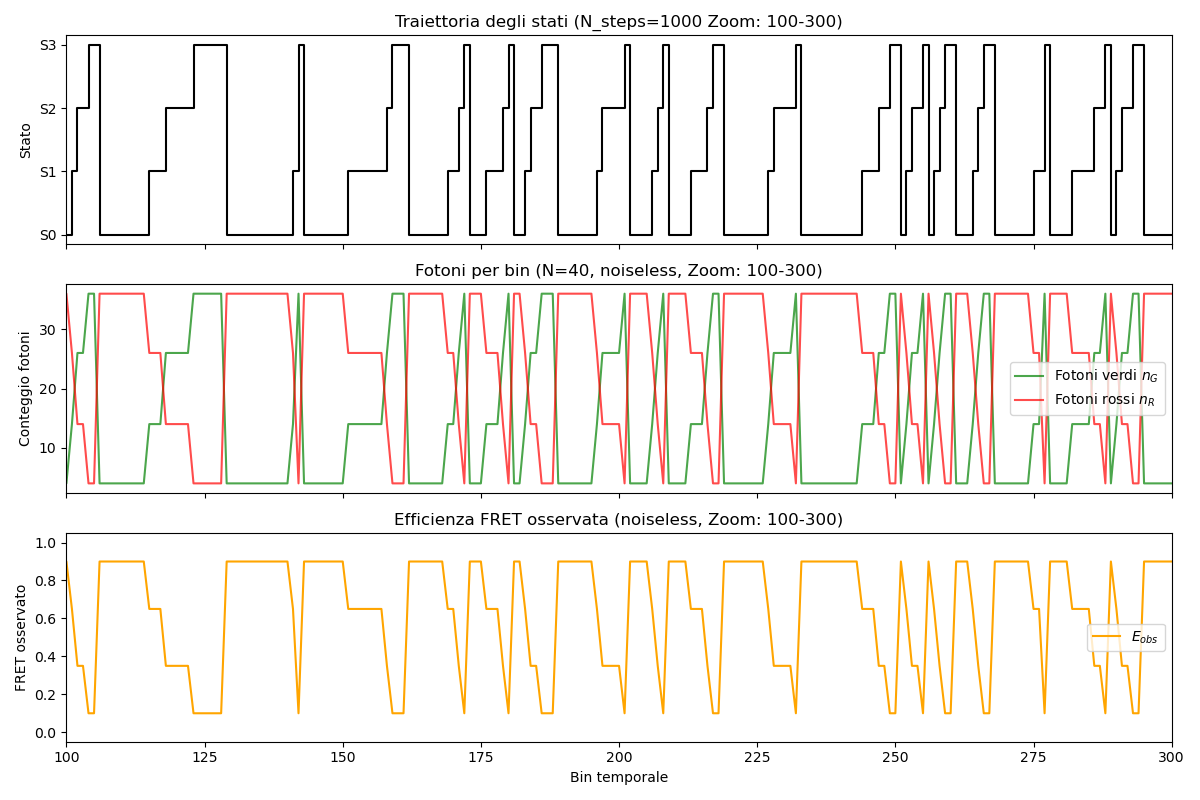

In [8]:
'''
Cella di visualizzazione della traiettoria e dei FRET osservati per N=40.
'''
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot della traiettoria degli stati
axes[0].step(range(len(trajectory)), trajectory, where='post', color='black')
axes[0].set_ylabel('Stato')
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(States)
axes[0].set_title(f'Traiettoria degli stati (N_steps={N_steps} Zoom: 100-300)')
axes[0].set_xlim(100, 300)

# Plot dei fotoni verdi e rossi
axes[1].plot(NumPhotons_G, color='green', alpha=0.7, label='Fotoni verdi $n_G$')
axes[1].plot(NumPhotons_R, color='red', alpha=0.7, label='Fotoni rossi $n_R$')
axes[1].set_ylabel('Conteggio fotoni')
axes[1].set_title(f'Fotoni per bin (N={N_Photons_start}, noiseless, Zoom: 100-300)')
axes[1].legend()
axes[1].set_xlim(100, 300)

# Plot di FRET_Obs_R
axes[2].plot(FRET_Obs[0], color='orange', label='$E_{obs}$')
axes[2].set_ylabel('FRET osservato')
axes[2].set_xlabel('Bin temporale')
axes[2].set_title(f'Efficienza FRET osservata (noiseless, Zoom: 100-300)')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend()
axes[2].set_xlim(100, 300)

plt.tight_layout()
plt.show()

In [9]:
'''
Cella di simulazione dei dati con rumore e visualizzazione.
'''

#Simulazione dei fotoni con rumore:
NumPhotons_G_NOISE, NumPhotons_R_NOISE, FRET_Obs_NOISE = CF.photon_simulation(trajectory, FRET_Initial_Article, N_Photons_start, noise=True)

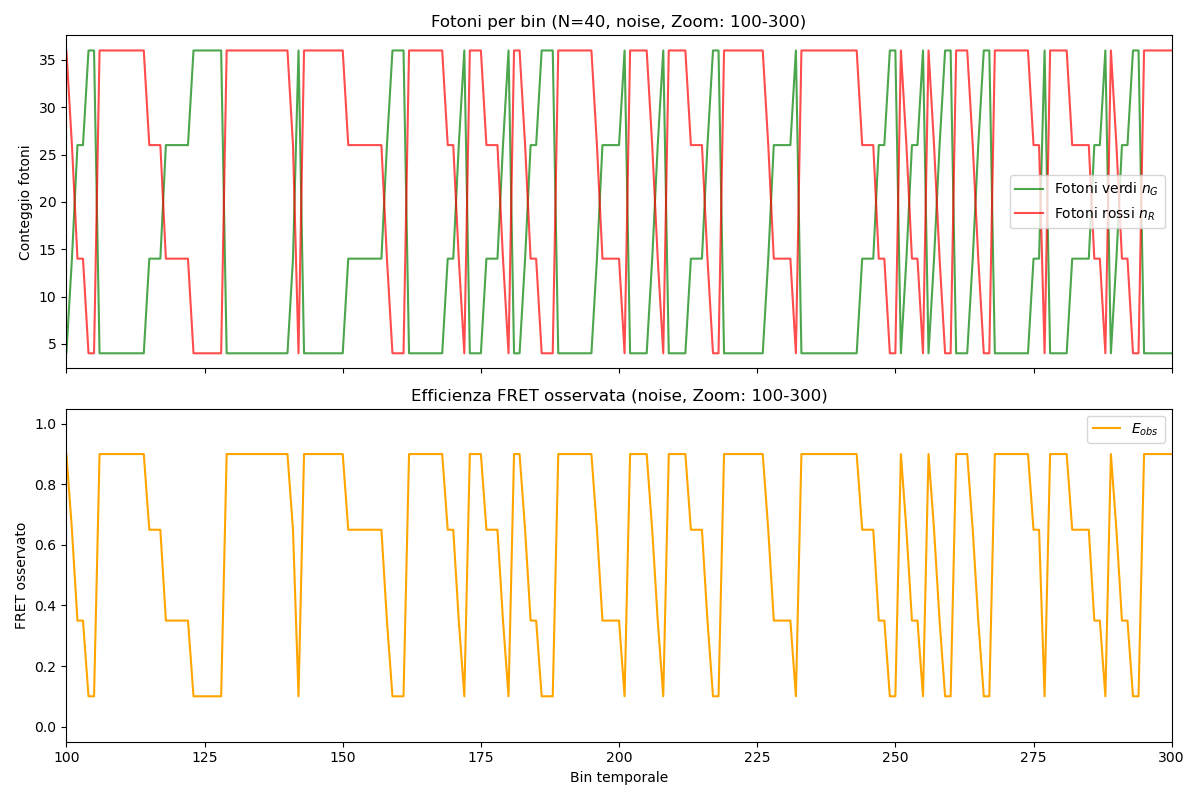

In [10]:
'''
Cella di visualizzazione della traiettoria e dei FRET osservati per N=40.
'''
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot dei fotoni verdi e rossi
axes[0].plot(NumPhotons_G, color='green', alpha=0.7, label='Fotoni verdi $n_G$')
axes[0].plot(NumPhotons_R, color='red', alpha=0.7, label='Fotoni rossi $n_R$')
axes[0].set_ylabel('Conteggio fotoni')
axes[0].set_title(f'Fotoni per bin (N={N_Photons_start}, noise, Zoom: 100-300)')
axes[0].legend()
axes[0].set_xlim(100, 300)

# Plot di FRET_Obs_R
axes[1].plot(FRET_Obs[0], color='orange', label='$E_{obs}$')
axes[1].set_ylabel('FRET osservato')
axes[1].set_xlabel('Bin temporale')
axes[1].set_title(f'Efficienza FRET osservata (noise, Zoom: 100-300)')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()
axes[1].set_xlim(100, 300)

plt.tight_layout()
plt.show()

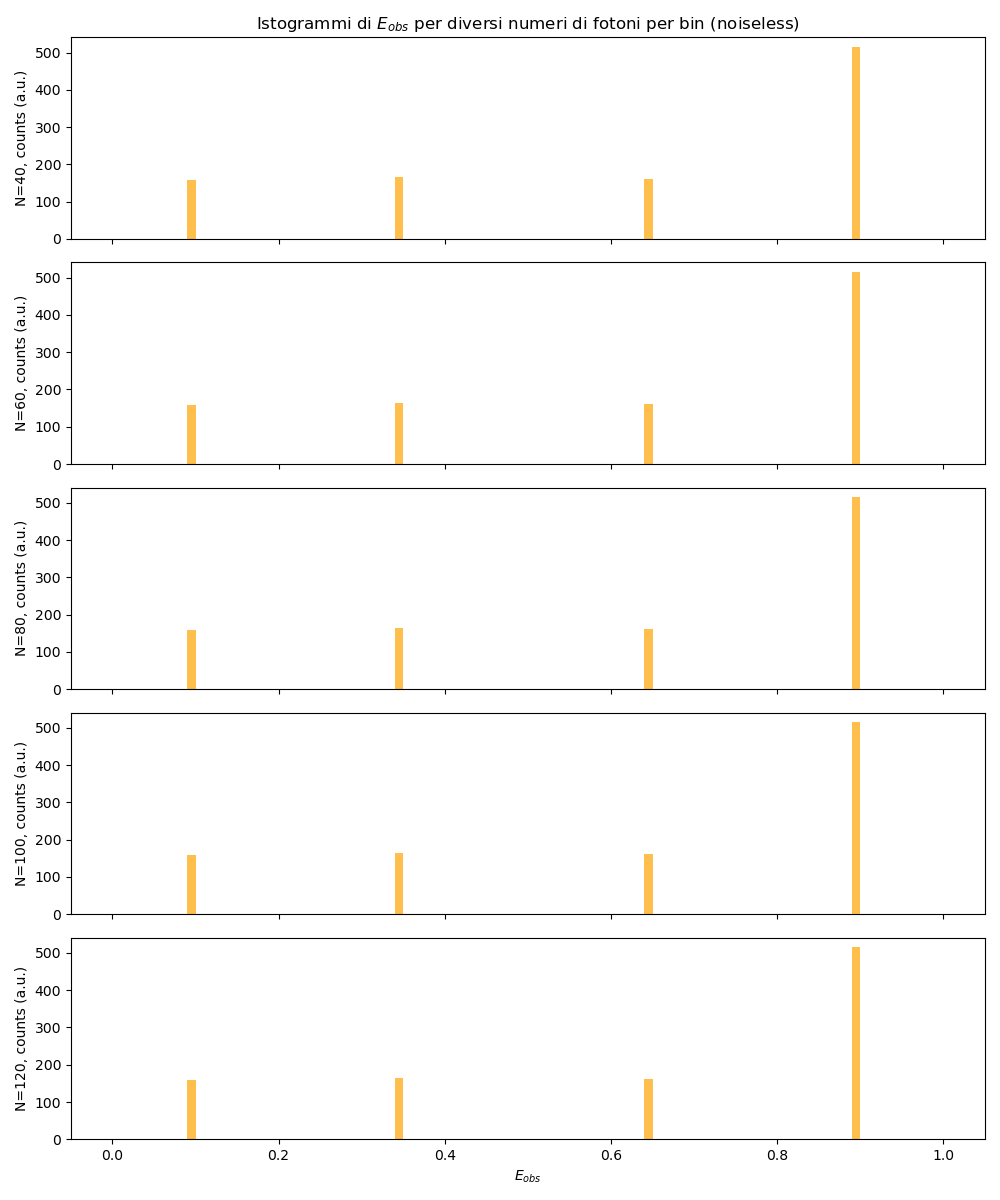

In [11]:
'''
Cella di visualizzazione degli istogrammi dei FRET osservati per diversi numeri di fotoni per bin senza rumore
'''


fig, axes = plt.subplots(len(N_Photons_simulations), 1, figsize=(10, 12), sharex=True)

for idx, N in enumerate(N_Photons_simulations):
    _, _, FRET_Obs_N = CF.photon_simulation(trajectory, FRET_Initial_Article, N, noise=False)
    axes[idx].hist(FRET_Obs_N[0], bins=100, range=(0,1), color='orange', alpha=0.7)
    axes[idx].set_ylabel(f'N={N}, counts (a.u.)')
axes[0].set_title('Istogrammi di $E_{obs}$ per diversi numeri di fotoni per bin (noiseless)')
axes[-1].set_xlabel('$E_{obs}$')
plt.tight_layout()

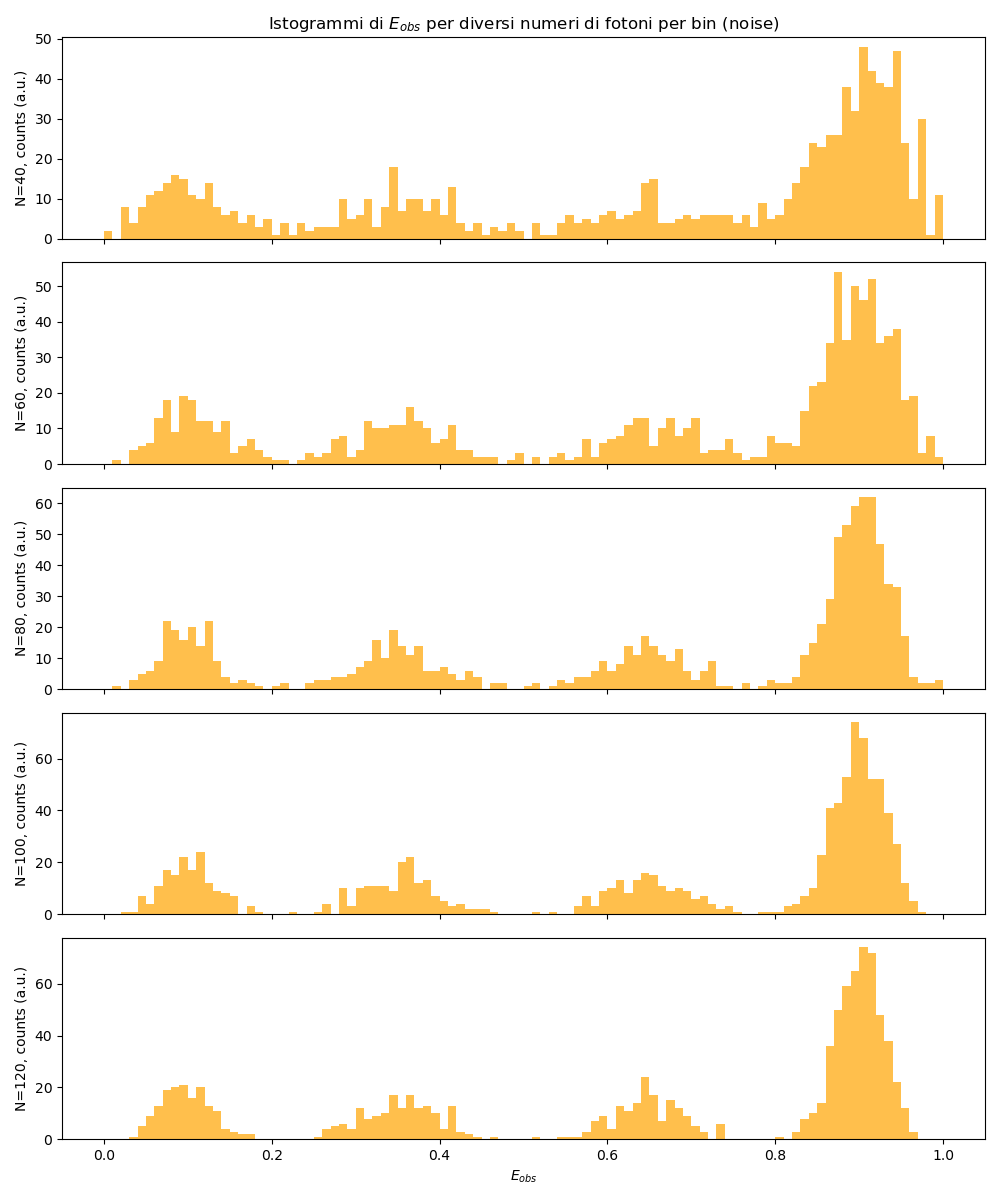

In [12]:
'''
Cella di visualizzazione degli istogrammi dei FRET osservati per diversi numeri di fotoni per bin con rumore
'''
fig, axes = plt.subplots(len(N_Photons_simulations), 1, figsize=(10, 12), sharex=True)

for idx, N in enumerate(N_Photons_simulations):
    _, _, FRET_Obs_N = CF.photon_simulation(trajectory, FRET_Initial_Article, N, noise=True)
    axes[idx].hist(FRET_Obs_N[0], bins=100, range=(0,1), color='orange', alpha=0.7)
    axes[idx].set_ylabel(f'N={N}, counts (a.u.)')
axes[0].set_title('Istogrammi di $E_{obs}$ per diversi numeri di fotoni per bin (noise)')
axes[-1].set_xlabel('$E_{obs}$')
plt.tight_layout()

**Osservazioni:**

- Dal momento che le variabili aleatorie presentate nei grafici precedenti sono l'esito del rapporto di distribuzioni poissoniane, non è possibile applicare l'approssimazione Gaussiana per procedere direttamente ad un semplice fit dei picchi per identificare il valore di $\sigma$ così da poter costruire il plot $\sigma$ vs $N$ per verificare la legge $\sigma=\frac{1}{\sqrt{N}}$ e determinare il valore di $N^*$ ottimale al fine di avere picchi ben distinti e separati tra loro. La soluzione risulta quindi essere quella di applicare un approccio non parametrico alla soluzione.
- Con approccio non parametrico si intende quindi la determinazione dei valori di $\sigma=\sqrt{\left\langle FRET_{obs}^2\right\rangle - \left\langle FRET_{obs}\right\rangle^2}$ per comporre il plot cercato e quindi procedere al fitting mediante la legge corretta $\sigma_{s}(N)=\sqrt{\frac{FRET_s(1-FRET_s)}{N}}$ dove $s$ indica lo stato scelto $(0,1,2,3)$. In particolare per identificare il valore ottimale di $N$ procederemo alla determinazione di esso tramite $\Delta FRET_{min}>(\sigma_i+\sigma_j)$ dove quindi ragioneremo a coppie di picchi vicini. L'idea alla base è quella che più i picchi sono distinti, più è ragionevole identificare se un fotone appartiene ad uno stato piuttosto che l'altro.

In [13]:
'''
Cella di determinazione delle std dei picchi mediante metodo non parametrico per l'identificazione del valore di N ottimale.
'''

sigmas = {E_s: [] for E_s in FRET_Initial_Article.values()}

#Ciclo di simulazione con successivo calcolo delle std per la legge da studiare.
for idx, N in enumerate(N_Photons_simulations):
    N_G, N_R, FRET_Obs = CF.photon_simulation(trajectory, FRET_Initial_Article, N, noise=True)
    FRET_Obs_bins = FRET_Obs[0]
    for E_s in FRET_Initial_Article.values():
        #Inizializzazione della maschera per i picchi.
        delta = 0.14
        mask_peak = np.abs(FRET_Obs_bins - E_s) < delta
        #Selezione dei valori di FRET osservato attorno al picco.
        E_selected = FRET_Obs_bins[mask_peak]
        #Calcolo non parametrico di media e deviazione standard.
        mean_s = np.mean(E_selected)
        std_s = np.std(E_selected, ddof=1)
        #Salvataggio della deviazione standard per il picco E_s.
        sigmas[E_s].append(std_s)


In [14]:
'''
Cella di fitting delle curve di std in funzione di N per i diversi picchi.
'''

from scipy.optimize import curve_fit

#Definizione della legge di scaling da studiare.
def scaling_law(N, A):
    return A / np.sqrt(N)

N_array = np.array(N_Photons_simulations, dtype=float)
fit_params = {}

for E_s in FRET_Initial_Article.values():
    sigma_array = np.array(sigmas[E_s])
    
    popt, pcov = curve_fit(scaling_law, N_array, sigma_array)
    perr = np.sqrt(np.diag(pcov))
    
    fit_params[E_s] = {
        'A_fit'    : popt[0],
        'A_err'    : perr[0],
        'A_theory' : np.sqrt(E_s * (1 - E_s))
    }
    
    print(f"E_s={E_s:.2f} | "
          f"A_fit={popt[0]:.4f} ± {perr[0]:.4f} | "
          f"A_theory={np.sqrt(E_s*(1-E_s)):.4f}")

E_s=0.90 | A_fit=0.3059 ± 0.0036 | A_theory=0.3000
E_s=0.65 | A_fit=0.4498 ± 0.0133 | A_theory=0.4770
E_s=0.35 | A_fit=0.4561 ± 0.0136 | A_theory=0.4770
E_s=0.10 | A_fit=0.3369 ± 0.0062 | A_theory=0.3000


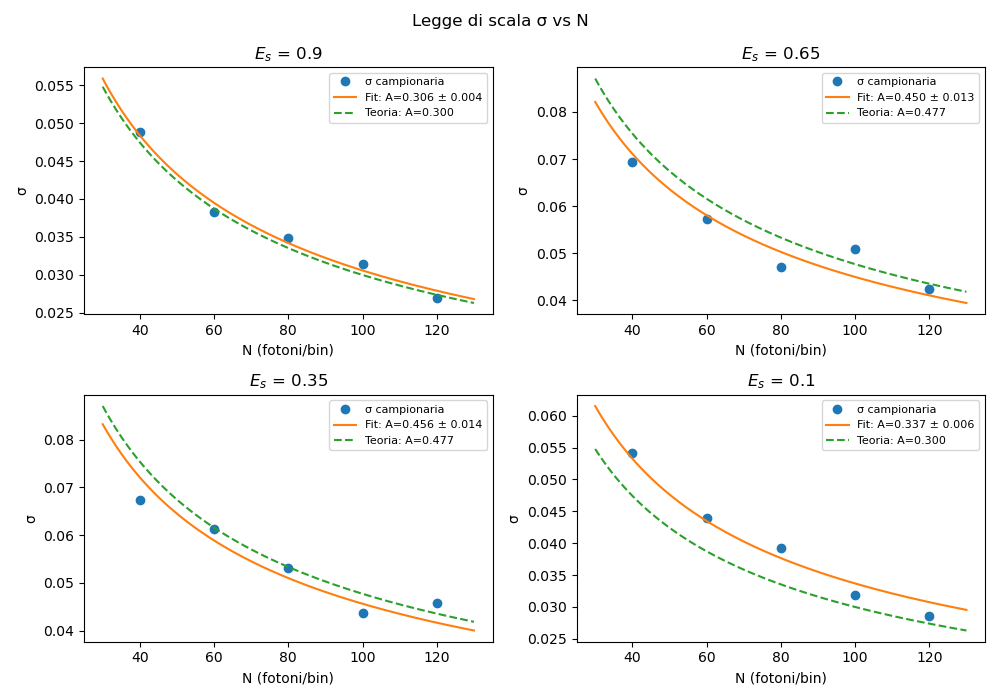

In [15]:
'''
Cella di visualizzazione della legge di scaling con i dati e i fit per i diversi picchi.
'''

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()
N_fine = np.linspace(30, 130, 200)

for ax, E_s in zip(axes, FRET_Initial_Article.values()):
    sigma_array = np.array(sigmas[E_s])
    A_fit    = fit_params[E_s]['A_fit']
    A_theory = fit_params[E_s]['A_theory']

    ax.plot(N_array, sigma_array, 'o', label='σ campionaria')
    ax.plot(N_fine, A_fit    / np.sqrt(N_fine), '-',  
            label=f'Fit: A={A_fit:.3f} ± {fit_params[E_s]["A_err"]:.3f}')
    ax.plot(N_fine, A_theory / np.sqrt(N_fine), '--', 
            label=f'Teoria: A={A_theory:.3f}')

    ax.set_xlabel('N (fotoni/bin)')
    ax.set_ylabel('σ')
    ax.set_title(f'$E_s$ = {E_s}')
    ax.legend(fontsize=8)

plt.suptitle('Legge di scala σ vs N')
plt.tight_layout()
plt.show()

**Osservazioni:**

- È necessario incrementare il numero delle traiettorie simulate come riportato nell'articolo al fine di migliorare la robustezza dei fit e quindi avere una stima più accurata di N ottimale.
- Qualitativamente la legge è verificata, ma bisogna fare un lavoro più approfondito per riuscire a trovare una corrispondenza quantitativa significativa.

**NOTA IMPORTANTE**

SIMONE: L'analisi non è ancora terminata alla data del 08/06/2026 e proseguirò nei prossimi giorni.